In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from medmnist import ChestMNIST
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

In [5]:
from torch.utils.data import Subset

torch.manual_seed(42)
np.random.seed(42)

transform_train = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

transform_test = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform_train)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform_test)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform_test)

indices_10k = torch.load('models/indices_10k.pth')
train_dataset = Subset(train_dataset, indices_10k)
val_dataset   = Subset(val_dataset,   range(2000))
test_dataset  = Subset(test_dataset,  range(3000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                          generator=torch.Generator().manual_seed(42))
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

label_names = ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
               'mass', 'nodule', 'pneumonia', 'pneumothorax',
               'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Data chargée | Device : {device}")

Data chargée | Device : cpu


In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=128):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


class ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, 
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=14):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = (img_size // patch_size) ** 2

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, 
            dim_feedforward=256, dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)

        cls_token = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_token, x], dim=1)
        x = x + self.pos_embed

        x = self.transformer(x)
        x = self.norm(x[:, 0])  # CLS token
        x = self.head(x)
        return x


model = ViT().to(device)
print("ViT chargé ")

ViT chargé 


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, inputs, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

torch.manual_seed(42)
np.random.seed(42)

criterion = FocalLoss(gamma=2.0, alpha=0.25)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print("Setup avec Focal Loss ")

Setup avec Focal Loss 


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=6):
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience = 3
    counter = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.float().to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device)
                labels = labels.float().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'models/vit_best.pth')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    model.load_state_dict(torch.load('models/vit_best.pth', map_location=device))
    print("Meilleur modèle rechargé ")
    return train_losses, val_losses

train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=6)

Epoch [1/6] | Train Loss: 0.0134 | Val Loss: 0.0129
Epoch [2/6] | Train Loss: 0.0130 | Val Loss: 0.0126
Epoch [3/6] | Train Loss: 0.0128 | Val Loss: 0.0126
Epoch [4/6] | Train Loss: 0.0128 | Val Loss: 0.0128
Epoch [5/6] | Train Loss: 0.0128 | Val Loss: 0.0125
Epoch [6/6] | Train Loss: 0.0127 | Val Loss: 0.0125
Meilleur modèle rechargé 


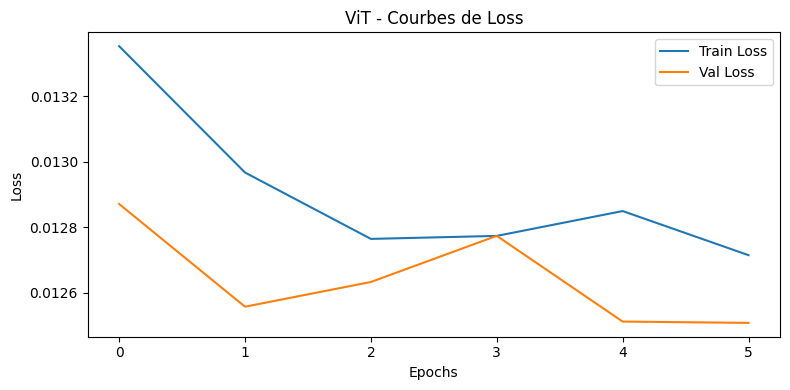

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ViT - Courbes de Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = torch.sigmoid(model(imgs))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_preds_binary = (all_preds >= 0.1).astype(int)

print("=" * 65)
print(f"{'Pathologie':<20} | {'AUC':>6} | {'F1':>6} | {'Recall':>6} | {'Precision':>9}")
print("=" * 65)

aucs, f1s, recalls, precisions = [], [], [], []
for i, name in enumerate(label_names):
    auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    f1 = f1_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    recall = recall_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    precision = precision_score(all_labels[:, i], all_preds_binary[:, i], zero_division=0)
    aucs.append(auc)
    f1s.append(f1)
    recalls.append(recall)
    precisions.append(precision)
    print(f"{name:<20} | {auc:>6.4f} | {f1:>6.4f} | {recall:>6.4f} | {precision:>9.4f}")

print("=" * 65)
print(f"{'Moyenne':<20} | {np.mean(aucs):>6.4f} | {np.mean(f1s):>6.4f} | {np.mean(recalls):>6.4f} | {np.mean(precisions):>9.4f}")

torch.save(model.state_dict(), 'models/vit.pth')
print("\nModèle sauvegardé ")

Pathologie           |    AUC |     F1 | Recall | Precision
atelectasis          | 0.6163 | 0.2031 | 1.0000 |    0.1130
cardiomegaly         | 0.5803 | 0.0557 | 1.0000 |    0.0287
effusion             | 0.6667 | 0.2343 | 1.0000 |    0.1327
infiltration         | 0.5757 | 0.3022 | 1.0000 |    0.1780
mass                 | 0.5093 | 0.0989 | 1.0000 |    0.0520
nodule               | 0.5415 | 0.1067 | 1.0000 |    0.0563
pneumonia            | 0.6181 | 0.0218 | 1.0000 |    0.0110
pneumothorax         | 0.5135 | 0.0928 | 1.0000 |    0.0487
consolidation        | 0.6442 | 0.0794 | 1.0000 |    0.0413
edema                | 0.7364 | 0.0431 | 1.0000 |    0.0220
emphysema            | 0.5206 | 0.0437 | 1.0000 |    0.0223
fibrosis             | 0.5658 | 0.0263 | 1.0000 |    0.0133
pleural              | 0.5383 | 0.0601 | 1.0000 |    0.0310
hernia               | 0.5616 | 0.0000 | 0.0000 |    0.0000
Moyenne              | 0.5849 | 0.0977 | 0.9286 |    0.0536

Modèle sauvegardé 
